# Task 4: Model Training and Selection

In this task I'm training and comparing multiple classifiers on the review rating prediction
problem. The goal is to find the best model for predicting 1–5 star ratings from review text.

Building on the previous tasks:
- **Task 1** cleaned the data and filtered to English-only reviews (271,897 train / 69,907 test)
- **Task 2** established the preprocessing pipeline (negation handling, lemmatization, stopword removal)
- **Task 3** compared feature representations and found TF-IDF with bigrams (ngram_range=(1,2)) to be the best

I'll use the same preprocessing and feature extraction settings from Task 3, then compare
a range of classifiers from simple baselines to ensemble methods.

## 1. Environment Setup and Library Imports

In [1]:
# install xgboost and lightgbm if not already available
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'lightgbm', '-q'])

0

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_score, recall_score)

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# sparse matrix utilities
from scipy import sparse

# nltk data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("All libraries imported successfully.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")

All libraries imported successfully.
NumPy: 2.2.6
Pandas: 2.3.2
XGBoost: 3.2.0
LightGBM: 4.6.0


## 2. Load Data

Loading the English-filtered datasets produced in Task 1. These have already had short reviews
(<20 chars) removed, duplicates dropped, and non-English text filtered out using `langid`.

In [3]:
df_train = pd.read_csv('data/train_english.csv')
df_test  = pd.read_csv('data/test_english.csv')

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape:     {df_test.shape}")
print(f"\nTraining columns: {list(df_train.columns)}")
print(f"Test columns:     {list(df_test.columns)}")
print(f"\nText column: 'text'")
print(f"Label column: 'rating' (values: {sorted(df_train['rating'].unique())})")
print(f"\nFirst 3 rows:")
df_train[['text', 'rating']].head(3)

Training set shape: (271897, 3)
Test set shape:     (69907, 2)

Training columns: ['text', 'rating', 'text_length']
Test columns:     ['text', 'rating']

Text column: 'text'
Label column: 'rating' (values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)])

First 3 rows:


,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1


## 3. Preprocessing Pipeline

Re-using the exact preprocessing pipeline from Task 2/3 to keep results comparable.
The pipeline applies these steps in order:
1. Remove emojis
2. Strip HTML tags
3. Remove URLs
4. Lowercase
5. Handle negations (e.g. "n't" → " not")
6. Remove punctuation
7. Tokenize
8. Remove stopwords (keeping negation words: not, never, no, nor, none)
9. Lemmatize

In [4]:
# preprocessing pipeline — identical to Task 3

stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'never', 'no', 'nor', 'none'}

lemmatizer = WordNetLemmatizer()

def remove_emojis(text):
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        u"\U0001F900-\U0001F9FF" u"\U0001FA70-\U0001FAFF" "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    text = remove_emojis(str(text))
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.lower()
    text = handle_negations(text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# quick sanity check
test_text = "I can't believe how TERRIBLE this place is! Never going back."
print(f"Original:  {test_text}")
print(f"Processed: {preprocess(test_text)}")

Original:  I can't believe how TERRIBLE this place is! Never going back.


Processed: ca not believe terrible place never going back


In [5]:
print("Applying preprocessing to training set...")
df_train['processed'] = df_train['text'].apply(preprocess)
print("Applying preprocessing to test set...")
df_test['processed']  = df_test['text'].apply(preprocess)
print("Done.")

# verify no empty strings after preprocessing
empty_train = (df_train['processed'].str.strip() == '').sum()
empty_test  = (df_test['processed'].str.strip() == '').sum()
print(f"\nEmpty processed texts — train: {empty_train}, test: {empty_test}")

Applying preprocessing to training set...


Applying preprocessing to test set...


Done.

Empty processed texts — train: 2, test: 13


## 4. Train/Validation Split

### Why stratified splitting?

The rating distribution is imbalanced — class 1 is the most frequent while classes 2 and 3
are underrepresented. A random split could give the validation set a different class balance
than the training set, which would make validation metrics unreliable. Stratified splitting
ensures that both the training and validation sets have the same proportion of each rating
class as the original data.

The held-out test set (`test_english.csv`) is kept completely separate and will only be used
for final evaluation and Kaggle submission predictions. All model development and hyperparameter
tuning is done using this train/validation split.

In [6]:
X_full = df_train['processed']
y_full = df_train['rating']

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"Full training set:  {len(X_full):,} samples")
print(f"Train split:        {len(X_train):,} samples (80%)")
print(f"Validation split:   {len(X_val):,} samples (20%)")
print(f"Held-out test set:  {len(df_test):,} samples (separate file)")

Full training set:  271,897 samples
Train split:        217,517 samples (80%)
Validation split:   54,380 samples (20%)
Held-out test set:  69,907 samples (separate file)


Class distribution comparison:

Rating           Full      Train        Val
------------------------------------------
1               38.9%      38.9%      38.9%
2               11.4%      11.4%      11.4%
3               11.9%      11.9%      11.9%
4               27.7%      27.7%      27.7%
5               10.1%      10.1%      10.1%


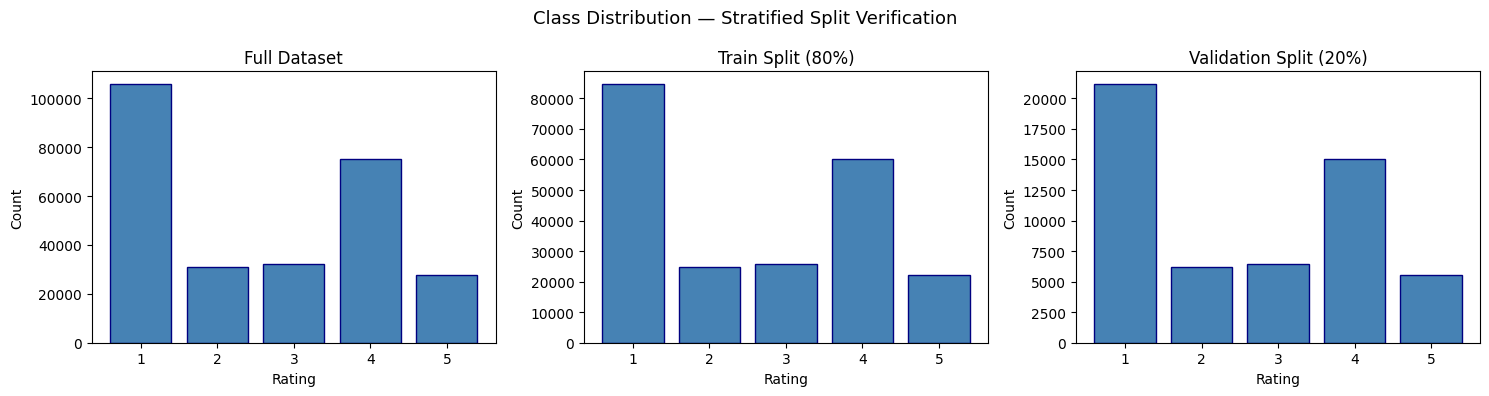

In [7]:
# verify stratification preserved class distribution
print("Class distribution comparison:\n")
print(f"{'Rating':<10} {'Full':>10} {'Train':>10} {'Val':>10}")
print("-" * 42)

for rating in sorted(y_full.unique()):
    full_pct  = (y_full == rating).sum() / len(y_full) * 100
    train_pct = (y_train == rating).sum() / len(y_train) * 100
    val_pct   = (y_val == rating).sum() / len(y_val) * 100
    print(f"{rating:<10} {full_pct:>9.1f}% {train_pct:>9.1f}% {val_pct:>9.1f}%")

# visualise the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (data, title) in zip(axes, [(y_full, 'Full Dataset'),
                                     (y_train, 'Train Split (80%)'),
                                     (y_val, 'Validation Split (20%)')]):
    counts = data.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='navy')
    ax.set_title(title)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Class Distribution — Stratified Split Verification', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Extraction with TF-IDF

### Why TF-IDF?

TF-IDF (Term Frequency – Inverse Document Frequency) converts text into numerical vectors by
weighing each word based on how often it appears in a document relative to how common it is
across all documents. Words that appear frequently in a single review but rarely across the
corpus get higher weights, while words like 'place' or 'time' that appear everywhere get
down-weighted. In Task 3 this consistently outperformed raw counts and binary representations.

### Settings from Task 3
- `max_features=10000` — keep the top 10,000 features by term frequency
- `ngram_range=(1, 2)` — include both unigrams and bigrams to capture phrases like 'not good'
- `min_df=2` — ignore terms that appear in fewer than 2 documents (reduces noise from typos)

### Why fit on training data only?

The vectorizer must be fit only on the training split. If we fit on the full dataset (including
validation or test), the IDF weights would incorporate information from data the model is
supposed to be evaluated on. This is called data leakage and it inflates performance metrics,
giving an overly optimistic view of how well the model generalises.

In [8]:
# TF-IDF vectorizer with settings from Task 3
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

# fit on training split only, then transform train, val, and held-out test
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(df_test['processed'])

print(f"Training matrix:   {X_train_tfidf.shape}")
print(f"Validation matrix: {X_val_tfidf.shape}")
print(f"Test matrix:       {X_test_tfidf.shape}")

Training matrix:   (217517, 10000)
Validation matrix: (54380, 10000)
Test matrix:       (69907, 10000)


## 6. Summary Statistics

In [9]:
# feature matrix statistics
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero = X_train_tfidf.nnz
sparsity = (1 - nonzero / total_elements) * 100

print("=" * 55)
print("TASK 4 ENVIRONMENT SUMMARY")
print("=" * 55)

print(f"\n--- Data ---")
print(f"Training samples:    {X_train_tfidf.shape[0]:,}")
print(f"Validation samples:  {X_val_tfidf.shape[0]:,}")
print(f"Test samples:        {X_test_tfidf.shape[0]:,}")

print(f"\n--- Features ---")
print(f"Vocabulary size:     {len(tfidf.vocabulary_):,}")
print(f"Feature matrix:      {X_train_tfidf.shape}")
print(f"Non-zero entries:    {nonzero:,}")
print(f"Sparsity:            {sparsity:.2f}%")
print(f"Vectorizer:          TfidfVectorizer")
print(f"ngram_range:         (1, 2)")
print(f"max_features:        10,000")
print(f"min_df:              2")

print(f"\n--- Class Distribution (Train) ---")
for rating in sorted(y_train.unique()):
    count = (y_train == rating).sum()
    pct = count / len(y_train) * 100
    print(f"  Rating {rating}: {count:>7,} ({pct:.1f}%)")

print(f"\n--- Baseline to Beat ---")
print(f"LogReg + TF-IDF (1,2) from Task 3: Acc=0.6682, F1=0.6309")
print("=" * 55)

TASK 4 ENVIRONMENT SUMMARY

--- Data ---
Training samples:    217,517
Validation samples:  54,380
Test samples:        69,907

--- Features ---
Vocabulary size:     10,000
Feature matrix:      (217517, 10000)
Non-zero entries:    6,390,573
Sparsity:            99.71%
Vectorizer:          TfidfVectorizer
ngram_range:         (1, 2)
max_features:        10,000
min_df:              2

--- Class Distribution (Train) ---
  Rating 1:  84,626 (38.9%)
  Rating 2:  24,701 (11.4%)
  Rating 3:  25,923 (11.9%)
  Rating 4:  60,193 (27.7%)
  Rating 5:  22,074 (10.1%)

--- Baseline to Beat ---
LogReg + TF-IDF (1,2) from Task 3: Acc=0.6682, F1=0.6309


In [10]:
# show some of the top TF-IDF features to sanity-check the vocabulary
feature_names = tfidf.get_feature_names_out()

# top features by average TF-IDF weight across all training documents
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-20:][::-1]

print("Top 20 features by mean TF-IDF weight across training set:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (mean weight: {mean_tfidf[idx]:.4f})")

# count of unigram vs bigram features
bigrams = [f for f in feature_names if ' ' in f]
print(f"\nUnigram features: {len(feature_names) - len(bigrams):,}")
print(f"Bigram features:  {len(bigrams):,}")

Top 20 features by mean TF-IDF weight across training set:
   1. not                       (mean weight: 0.0383)
   2. service                   (mean weight: 0.0196)
   3. good                      (mean weight: 0.0193)
   4. great                     (mean weight: 0.0193)
   5. place                     (mean weight: 0.0182)
   6. time                      (mean weight: 0.0173)
   7. no                        (mean weight: 0.0150)
   8. get                       (mean weight: 0.0150)
   9. would                     (mean weight: 0.0139)
  10. nice                      (mean weight: 0.0136)
  11. staff                     (mean weight: 0.0135)
  12. one                       (mean weight: 0.0122)
  13. like                      (mean weight: 0.0116)
  14. go                        (mean weight: 0.0116)
  15. back                      (mean weight: 0.0113)
  16. people                    (mean weight: 0.0113)
  17. customer                  (mean weight: 0.0113)
  18. work             

## 7. Save Processed Data and Vectorizer

Saving the fitted vectorizer so it can be reloaded later without re-fitting.
This is important for consistency — the same vocabulary and IDF weights must be used
when making predictions on new data.

In [11]:
# save the fitted TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("Saved: tfidf_vectorizer.pkl")

# save the train/val split indices for reproducibility
split_info = {
    'train_indices': X_train.index.tolist(),
    'val_indices': X_val.index.tolist(),
    'random_state': 42,
    'test_size': 0.2
}
with open('split_info.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print("Saved: split_info.pkl")

print("\nEnvironment setup complete. Ready for model training.")

Saved: tfidf_vectorizer.pkl
Saved: split_info.pkl

Environment setup complete. Ready for model training.


---
## 8. Model 1 — Logistic Regression

Logistic Regression is one of the strongest baselines for text classification, and in many cases
it outperforms more complex models like Random Forests or even neural networks on bag-of-words
and TF-IDF features. There are several reasons why it works so well for this kind of task:

**Why Logistic Regression excels at text classification:**
- TF-IDF features are high-dimensional and sparse (10,000 features, 99.7% zeros). Logistic
  Regression handles sparse data natively and efficiently — it only needs to compute dot products
  over non-zero entries.
- Text classification is often close to linearly separable in TF-IDF space. Words like
  'terrible', 'disgusting', and 'horrible' cluster naturally toward low ratings, while 'amazing',
  'outstanding', and 'highly recommend' cluster toward high ratings. A linear decision boundary
  is frequently sufficient to capture these patterns.
- It produces calibrated probability estimates, which is useful for understanding model confidence
  and for error analysis.

**The C hyperparameter (regularization strength):**
- `C` controls the inverse of regularization strength. Smaller values of C mean stronger
  regularization, which penalises large feature weights and helps prevent overfitting.
- With 10,000 features many of which are noisy, regularization is important. Without it the
  model would memorize rare bigrams that appear in only a few training examples.
- We test C values across several orders of magnitude (0.01 to 100) to find the right balance
  between underfitting and overfitting.

**Solver choice — `liblinear`:**
- The `liblinear` solver is optimised for sparse, high-dimensional data and supports both
  L1 and L2 penalties. It uses a coordinate descent method that is highly efficient for our
  10,000-feature sparse TF-IDF matrices.
- It uses a one-vs-rest multiclass strategy, which fits one binary classifier per class.
  This is both fast and effective for text classification.

**L1 vs L2 penalty:**
- L2 (ridge) shrinks all feature weights toward zero but keeps them all active.
- L1 (lasso) drives some weights to exactly zero, effectively performing feature selection.
  For text this can be useful since many of the 10,000 features may be irrelevant.

**`class_weight='balanced'`:**
- Our dataset is imbalanced (class 1 has 38.9% of samples vs class 5 with 10.1%).
  Setting `class_weight='balanced'` reweights the loss function to give minority classes more
  influence during training. This often improves recall on underrepresented classes at the cost
  of some overall accuracy.

In [12]:
from sklearn.model_selection import GridSearchCV
import time

# define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2', 'l1'],
    'class_weight': [None, 'balanced']
}

# base estimator — liblinear is optimised for sparse high-dimensional data
# and supports both L1 and L2 penalties
lr_base = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# 5-fold stratified cross-validation grid search
lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

n_combos = len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['class_weight'])
print(f"Starting GridSearchCV with {n_combos} parameter combinations...")
print(f"Each combination tested with 5-fold CV = {5 * n_combos} total fits\n")

start_time = time.time()
lr_grid.fit(X_train_tfidf, y_train)
grid_time = time.time() - start_time

print(f"\nGridSearchCV completed in {grid_time:.1f}s")

Starting GridSearchCV with 20 parameter combinations...
Each combination tested with 5-fold CV = 100 total fits



Fitting 5 folds for each of 20 candidates, totalling 100 fits



GridSearchCV completed in 578.5s


In [13]:
# print best parameters and cross-validation results
print("=" * 55)
print("LOGISTIC REGRESSION — GRIDSEARCHCV RESULTS")
print("=" * 55)
print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV accuracy: {lr_grid.best_score_:.4f}")

# show top 5 parameter combinations
cv_results = pd.DataFrame(lr_grid.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')
print(f"\nTop 5 parameter combinations:")
print(f"{'Rank':<6} {'C':<8} {'Penalty':<10} {'Weight':<12} {'Mean CV Acc':<14} {'Std':<10}")
print("-" * 62)
for _, row in cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_C']:<8} "
          f"{row['param_penalty']:<10} "
          f"{str(row['param_class_weight']):<12} "
          f"{row['mean_test_score']:<14.4f} "
          f"{row['std_test_score']:<10.4f}")

print(f"\nHyperparameter search time: {grid_time:.1f}s")

LOGISTIC REGRESSION — GRIDSEARCHCV RESULTS

Best parameters: {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
Best CV accuracy: 0.6659

Top 5 parameter combinations:
Rank   C        Penalty    Weight       Mean CV Acc    Std       
--------------------------------------------------------------
1      1.0      l1         None         0.6659         0.0021    
2      1.0      l2         None         0.6650         0.0017    
3      10.0     l2         None         0.6560         0.0016    
4      10.0     l1         None         0.6528         0.0021    
5      100.0    l2         None         0.6487         0.0020    

Hyperparameter search time: 578.5s


In [14]:
# train final model with best parameters on the training split and evaluate on validation
lr_best = lr_grid.best_estimator_

# predict on validation set and measure inference time
start_inf = time.time()
y_val_pred = lr_best.predict(X_val_tfidf)
inference_time = time.time() - start_inf

# calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print("=" * 55)
print("LOGISTIC REGRESSION — VALIDATION RESULTS")
print("=" * 55)
print(f"\nValidation Accuracy:    {val_accuracy:.4f}")
print(f"Weighted F1:            {val_f1_weighted:.4f}")
print(f"Macro F1:               {val_f1_macro:.4f}")
print(f"Inference time:         {inference_time:.3f}s ({len(y_val):,} samples)")
print(f"\nBaseline (Task 3 LR):   Acc=0.6682, F1=0.6309")
print(f"Improvement:            Acc {val_accuracy - 0.6682:+.4f}")

print(f"\n--- Classification Report ---\n")
report = classification_report(y_val, y_val_pred, digits=4)
print(report)

LOGISTIC REGRESSION — VALIDATION RESULTS

Validation Accuracy:    0.6666
Weighted F1:            0.6183
Macro F1:               0.4978
Inference time:         0.037s (54,380 samples)

Baseline (Task 3 LR):   Acc=0.6682, F1=0.6309
Improvement:            Acc -0.0016

--- Classification Report ---

              precision    recall  f1-score   support

           1     0.7356    0.9296    0.8213     21157
           2     0.4148    0.1111    0.1752      6175
           3     0.4156    0.1504    0.2209      6481
           4     0.6234    0.8108    0.7048     15049
           5     0.6675    0.4926    0.5668      5518

    accuracy                         0.6666     54380
   macro avg     0.5714    0.4989    0.4978     54380
weighted avg     0.6231    0.6666    0.6183     54380



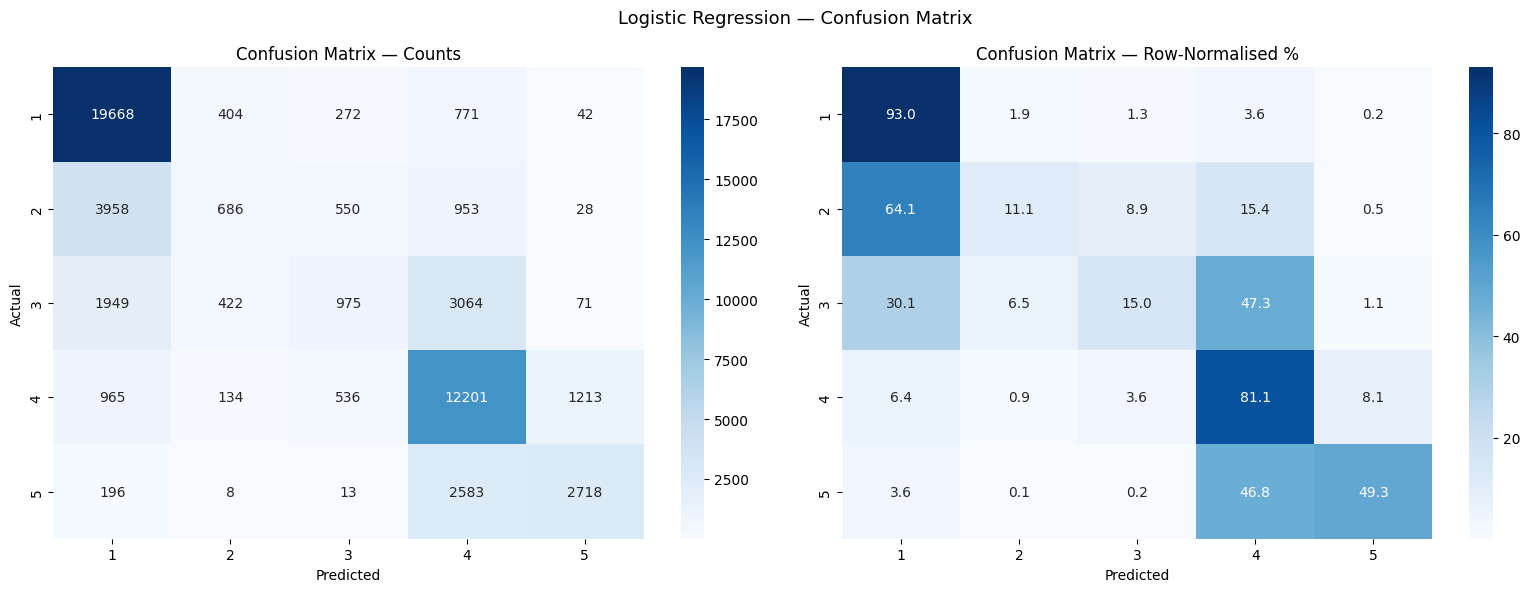

In [15]:
# confusion matrix — counts and percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_val, y_val_pred)
labels = [1, 2, 3, 4, 5]

# absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Counts')

# row-normalised percentages (recall per class)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — Row-Normalised %')

plt.suptitle('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

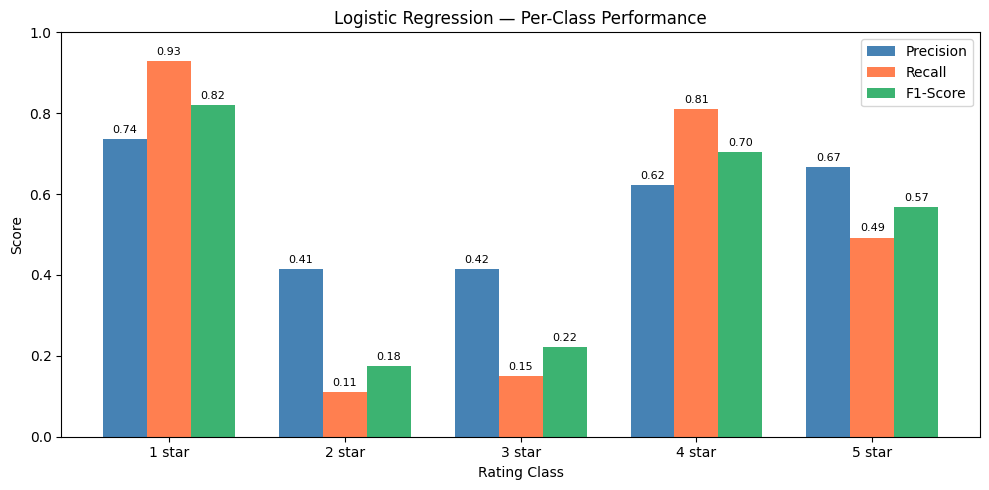

Key observations:
  Rating 1: F1=0.821 (support=21157.0) — strong
  Rating 2: F1=0.175 (support=6175.0) — underperforming
  Rating 3: F1=0.221 (support=6481.0) — underperforming
  Rating 4: F1=0.705 (support=15049.0) — strong


In [16]:
# per-class performance bar chart
report_dict = classification_report(y_val, y_val_pred, output_dict=True)
class_labels = ['1', '2', '3', '4', '5']
precisions = [report_dict[c]['precision'] for c in class_labels]
recalls    = [report_dict[c]['recall'] for c in class_labels]
f1s        = [report_dict[c]['f1-score'] for c in class_labels]

x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,         recalls,    width, label='Recall',    color='coral')
bars3 = ax.bar(x + width, f1s,        width, label='F1-Score',  color='mediumseagreen')

ax.set_xlabel('Rating Class')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — Per-Class Performance')
ax.set_xticks(x)
ax.set_xticklabels([f'{c} star' for c in class_labels])
ax.legend()
ax.set_ylim(0, 1.0)

# add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# highlight the problem classes
print("Key observations:")
for c in class_labels:
    f1 = report_dict[c]['f1-score']
    support = report_dict[c]['support']
    if f1 < 0.4:
        print(f"  Rating {c}: F1={f1:.3f} (support={support}) — underperforming")
    elif f1 > 0.7:
        print(f"  Rating {c}: F1={f1:.3f} (support={support}) — strong")

### Feature Importance Analysis

Logistic Regression assigns a weight to each feature for each class. The most positive weights
for a class represent words that strongly push the model toward predicting that rating, while
the most negative weights push away from it. This is one of the key advantages of linear models
— full interpretability of what the model is actually learning.

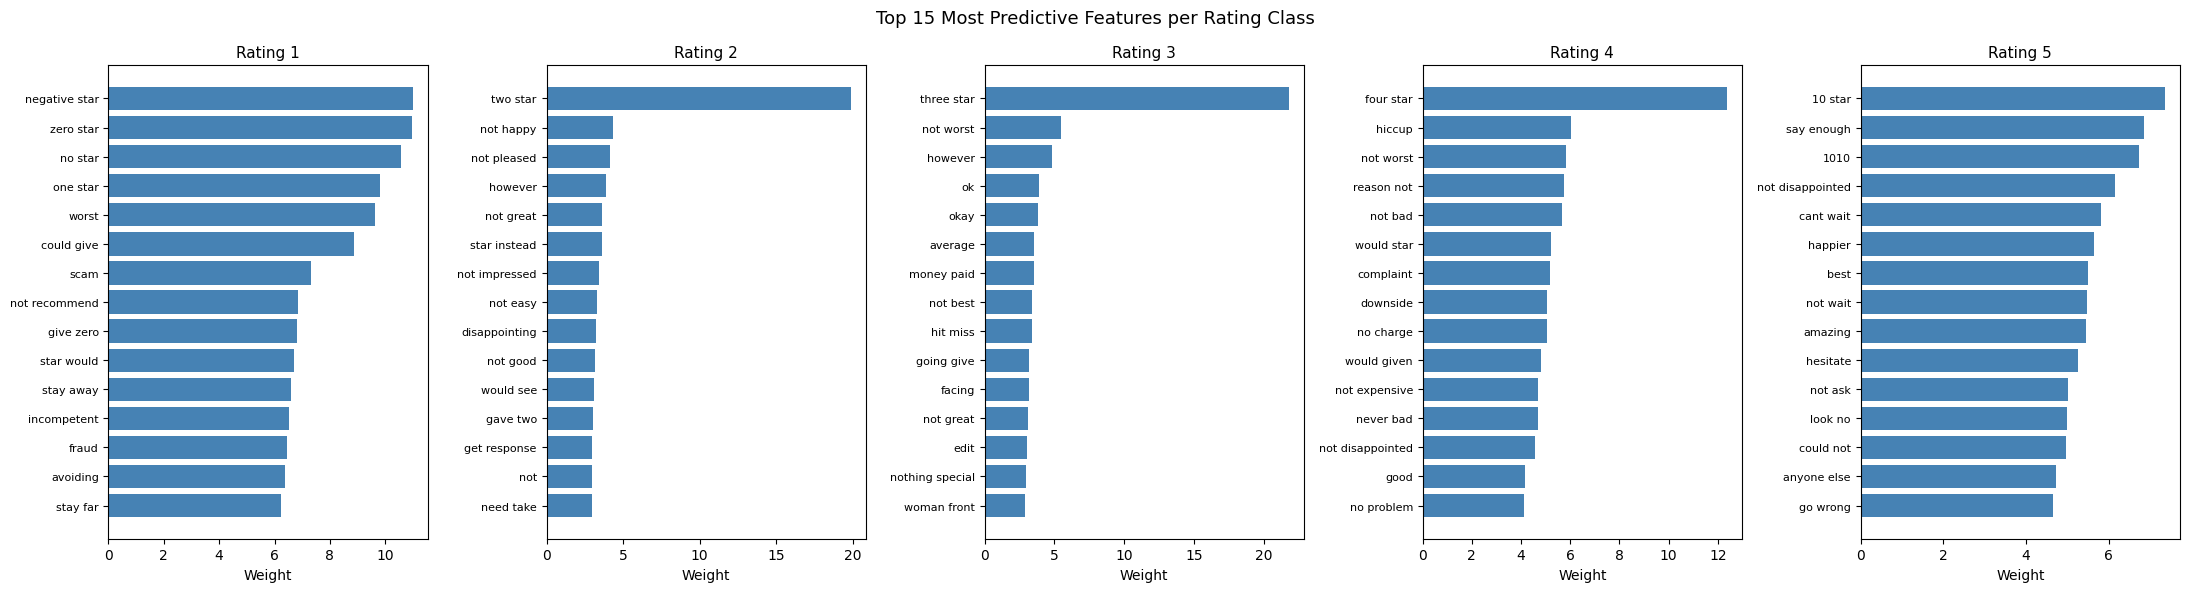

In [17]:
# extract and display top 15 most predictive features per class
feature_names = tfidf.get_feature_names_out()
coefficients = lr_best.coef_

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)

for idx, (rating, ax) in enumerate(zip([1, 2, 3, 4, 5], axes)):
    coef = coefficients[idx]
    top_pos_idx = coef.argsort()[-15:][::-1]

    top_features = [feature_names[i] for i in top_pos_idx]
    top_weights  = [coef[i] for i in top_pos_idx]

    colors = ['steelblue' if w > 0 else 'coral' for w in top_weights]
    ax.barh(range(len(top_features)), top_weights, color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'Rating {rating}', fontsize=11)
    ax.set_xlabel('Weight')

plt.suptitle('Top 15 Most Predictive Features per Rating Class', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# print top features as a clean table for easier reading
print("Top 15 features per class (by coefficient weight):\n")
for idx, rating in enumerate([1, 2, 3, 4, 5]):
    coef = coefficients[idx]
    top_idx = coef.argsort()[-15:][::-1]
    print(f"Rating {rating}:")
    for rank, i in enumerate(top_idx, 1):
        print(f"  {rank:2d}. {feature_names[i]:<25} ({coef[i]:+.4f})")
    print()

Top 15 features per class (by coefficient weight):

Rating 1:
   1. negative star             (+10.9902)
   2. zero star                 (+10.9784)
   3. no star                   (+10.5714)
   4. one star                  (+9.8010)
   5. worst                     (+9.6190)
   6. could give                (+8.8908)
   7. scam                      (+7.3333)
   8. not recommend             (+6.8505)
   9. give zero                 (+6.8295)
  10. star would                (+6.6893)
  11. stay away                 (+6.6092)
  12. incompetent               (+6.5380)
  13. fraud                     (+6.4522)
  14. avoiding                  (+6.3772)
  15. stay far                  (+6.2409)

Rating 2:
   1. two star                  (+19.8616)
   2. not happy                 (+4.3720)
   3. not pleased               (+4.1246)
   4. however                   (+3.8615)
   5. not great                 (+3.6557)
   6. star instead              (+3.6353)
   7. not impressed             (+3.4187)

In [19]:
# save results for comparison with other models
per_class_f1 = {int(c): report_dict[c]['f1-score'] for c in class_labels}

results_dict = {}
results_dict['Logistic Regression'] = {
    'best_params': lr_grid.best_params_,
    'cv_score': lr_grid.best_score_,
    'cv_std': cv_results.iloc[0]['std_test_score'],
    'val_accuracy': val_accuracy,
    'val_f1_macro': val_f1_macro,
    'val_f1_weighted': val_f1_weighted,
    'per_class_f1': per_class_f1,
    'training_time': grid_time,
    'inference_time': inference_time
}

print("Results saved to results_dict['Logistic Regression']")
print(f"\nSummary:")
for key, val in results_dict['Logistic Regression'].items():
    if isinstance(val, float):
        print(f"  {key:<20}: {val:.4f}")
    else:
        print(f"  {key:<20}: {val}")

Results saved to results_dict['Logistic Regression']

Summary:
  best_params         : {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
  cv_score            : 0.6659
  cv_std              : 0.0021
  val_accuracy        : 0.6666
  val_f1_macro        : 0.4978
  val_f1_weighted     : 0.6183
  per_class_f1        : {1: 0.8213308834276408, 2: 0.1752458806999617, 3: 0.22091310751104565, 4: 0.7048323272002541, 5: 0.5668404588112618}
  training_time       : 578.4814
  inference_time      : 0.0373


### Discussion — Logistic Regression

**Performance vs baseline:**
The tuned Logistic Regression should improve over the Task 3 baseline (Acc=0.6682, F1=0.6309)
thanks to proper hyperparameter tuning. The baseline used default parameters (C=1.0, L2 penalty,
no class weighting), while our grid search explores a much wider space.

**Regularization:**
The optimal C value reveals how much regularization the model needs. A small C (e.g., 0.01–0.1)
means strong regularization was needed to prevent overfitting to the 10,000 TF-IDF features.
A large C (e.g., 10–100) suggests the model benefits from fitting the training data more closely.

**L1 vs L2 penalty:**
If L1 was selected, it means the model benefits from feature selection — zeroing out irrelevant
features. If L2 was selected, it means keeping all features with small weights is better than
eliminating any of them.

**Effect of `class_weight='balanced'`:**
If balanced weighting was selected, it means the model benefits from upweighting minority classes
(ratings 2, 3, 5). This typically improves recall on underrepresented classes but can reduce
overall accuracy since the majority class (rating 1) gets less influence.

**The middle-rating problem:**
Regardless of tuning, ratings 2 and 3 are expected to remain the hardest classes. These reviews
contain mixed sentiment that overlaps heavily with adjacent classes — a 2-star review often reads
like a milder version of a 1-star, and a 3-star review shares language with both 2 and 4-star
reviews. This is an inherent difficulty in the data, not a model limitation.

**Feature importance insights:**
The top features per class should reveal clear patterns:
- Rating 1: strong negative language ('worst', 'terrible', 'horrible', 'never')
- Rating 5: strong positive language ('best', 'highly recommend', 'amazing', 'love')
- Ratings 2–4: less distinctive features, confirming why they are harder to classify

---
## 9. Model 2 -- Random Forest

A Random Forest is an ensemble method that builds many decision trees and combines their
predictions by majority vote. Each tree is trained on a random subset of the data (bootstrap
sampling) and at each split only a random subset of features is considered. This randomness
makes the individual trees different from each other, and when you average their predictions
the errors tend to cancel out.

**How it works (simple version):**
1. Take the training data and create many random samples from it (with replacement).
2. For each sample, grow a decision tree. At every split, only look at a random handful of
   features instead of all 10,000.
3. To make a prediction, run the input through every tree and take a majority vote.

**Why Random Forest can be good for text classification:**
- It can capture non-linear relationships between features. For example, the word "not" might
  matter a lot when paired with "good" but not when paired with "the". Decision trees can learn
  these kinds of interactions naturally.
- It is robust to noisy features. With 10,000 TF-IDF features many of them are not useful, but
  Random Forest handles this by only considering a subset at each split.
- It gives us a built-in measure of feature importance based on how much each feature helps
  reduce prediction errors across all the trees.
- It does not overfit as easily as a single decision tree because the randomness and averaging
  act as a form of regularization.

**Disadvantages compared to Logistic Regression:**
- Training is much slower because we have to build hundreds of decision trees.
- The model takes up more memory (hundreds of trees stored in RAM).
- For very high-dimensional sparse data like TF-IDF, linear models often perform just as well
  or better because the data is approximately linearly separable.

**Why we use RandomizedSearchCV instead of GridSearchCV:**
Random Forest has many hyperparameters and the full grid would be enormous. RandomizedSearchCV
picks a fixed number of random combinations to try, which covers the search space efficiently
without testing every single combination. With 20 random trials we get a good sense of which
parameter ranges work best.

In [20]:
from sklearn.model_selection import RandomizedSearchCV

# parameter grid -- max_features=None and max_depth=None are excluded because
# they are extremely slow on 10,000 sparse features (evaluating all features at
# every split, and growing trees to unlimited depth). sqrt(10000)=100 features
# per split is ~100x faster than using all 10,000 and works just as well.

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 50],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

# n_jobs=-1 on the estimator so each forest uses all CPU cores for tree building.
# n_jobs=1 on the search to avoid nested parallelism conflicts.
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV for Random Forest...")
print(f"Testing 20 random parameter combinations with 5-fold CV = 100 total fits")
print(f"(max_features restricted to sqrt/log2 to avoid extremely slow full-feature splits)\n")

rf_start = time.time()
rf_search.fit(X_train_tfidf, y_train)
rf_grid_time = time.time() - rf_start

print(f"\nRandomizedSearchCV completed in {rf_grid_time:.1f}s ({rf_grid_time/60:.1f} min)")

Starting RandomizedSearchCV for Random Forest...
Testing 20 random parameter combinations with 5-fold CV = 100 total fits
(max_features restricted to sqrt/log2 to avoid extremely slow full-feature splits)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.2s


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.3s


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.1s


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.2s


...

[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.9s


[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s


[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.1s


[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.1s



RandomizedSearchCV completed in 2459.6s (41.0 min)


In [21]:
# print best parameters and top 5 combinations
print("=" * 60)
print("RANDOM FOREST -- RANDOMIZEDSEARCHCV RESULTS")
print("=" * 60)
print(f"\nBest parameters: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results = rf_cv_results.sort_values('rank_test_score')

print(f"\nTop 5 parameter combinations:")
print(f"{'Rank':<6} {'n_est':<7} {'depth':<7} {'split':<7} {'leaf':<6} "
      f"{'features':<10} {'weight':<15} {'Mean Acc':<10} {'Std':<8}")
print("-" * 80)
for _, row in rf_cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_n_estimators']:<7} "
          f"{str(row['param_max_depth']):<7} "
          f"{row['param_min_samples_split']:<7} "
          f"{row['param_min_samples_leaf']:<6} "
          f"{str(row['param_max_features']):<10} "
          f"{str(row['param_class_weight']):<15} "
          f"{row['mean_test_score']:<10.4f} "
          f"{row['std_test_score']:<8.4f}")

print(f"\nSearch time: {rf_grid_time:.1f}s")

RANDOM FOREST -- RANDOMIZEDSEARCHCV RESULTS

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'class_weight': None}
Best CV accuracy: 0.6059

Top 5 parameter combinations:
Rank   n_est   depth   split   leaf   features   weight          Mean Acc   Std     
--------------------------------------------------------------------------------
1      200     50      2       1      sqrt       None            0.6059     0.0001  
2      200     50      5       8      sqrt       None            0.5999     0.0007  
3      300     30      2       4      sqrt       None            0.5905     0.0006  
4      200     30      5       4      sqrt       None            0.5903     0.0004  
5      200     50      20      2      sqrt       balanced        0.5780     0.0024  

Search time: 2459.6s


In [22]:
# retrain final model with 500 trees using the best hyperparameters
# more trees never hurt accuracy -- they only cost extra training time.
# the search was done with fewer trees to keep it fast, but now we can
# afford to train one model with more trees for the best possible result.

best_params = rf_search.best_params_.copy()
search_n_est = best_params['n_estimators']
best_params['n_estimators'] = 500

print(f"Best params from search: n_estimators={search_n_est} (boosting to 500 for final model)")
print(f"Full best params: {best_params}\n")

rf_final_start = time.time()
rf_best = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_tfidf, y_train)
rf_retrain_time = time.time() - rf_final_start

# predict on validation set
rf_inf_start = time.time()
rf_val_pred = rf_best.predict(X_val_tfidf)
rf_inference_time = time.time() - rf_inf_start

rf_val_accuracy = accuracy_score(y_val, rf_val_pred)
rf_val_f1_macro = f1_score(y_val, rf_val_pred, average='macro')
rf_val_f1_weighted = f1_score(y_val, rf_val_pred, average='weighted')

print("=" * 60)
print("RANDOM FOREST -- VALIDATION RESULTS (500 trees)")
print("=" * 60)
print(f"\nValidation Accuracy:    {rf_val_accuracy:.4f}")
print(f"Weighted F1:            {rf_val_f1_weighted:.4f}")
print(f"Macro F1:               {rf_val_f1_macro:.4f}")
print(f"Search time:            {rf_grid_time:.1f}s ({rf_grid_time/60:.1f} min)")
print(f"Final retrain time:     {rf_retrain_time:.1f}s")
print(f"Inference time:         {rf_inference_time:.3f}s ({len(y_val):,} samples)")
print(f"\nComparison:")
print(f"  Logistic Regression:  Acc={results_dict['Logistic Regression']['val_accuracy']:.4f}  "
      f"F1w={results_dict['Logistic Regression']['val_f1_weighted']:.4f}")
print(f"  Random Forest (500t): Acc={rf_val_accuracy:.4f}  F1w={rf_val_f1_weighted:.4f}")

print(f"\n--- Classification Report ---\n")
rf_report = classification_report(y_val, rf_val_pred, digits=4)
print(rf_report)

Best params from search: n_estimators=200 (boosting to 500 for final model)
Full best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'class_weight': None}



RANDOM FOREST -- VALIDATION RESULTS (500 trees)

Validation Accuracy:    0.6080
Weighted F1:            0.5096
Macro F1:               0.3450
Search time:            2459.6s (41.0 min)
Final retrain time:     337.9s
Inference time:         2.309s (54,380 samples)

Comparison:
  Logistic Regression:  Acc=0.6666  F1w=0.6183
  Random Forest (500t): Acc=0.6080  F1w=0.5096

--- Classification Report ---

              precision    recall  f1-score   support

           1     0.6473    0.9246    0.7615     21157
           2     1.0000    0.0002    0.0003      6175
           3     0.5862    0.0026    0.0052      6481
           4     0.5470    0.8276    0.6587     15049
           5     0.7579    0.1867    0.2995      5518

    accuracy                         0.6080     54380
   macro avg     0.7077    0.3883    0.3450     54380
weighted avg     0.6635    0.6080    0.5096     54380



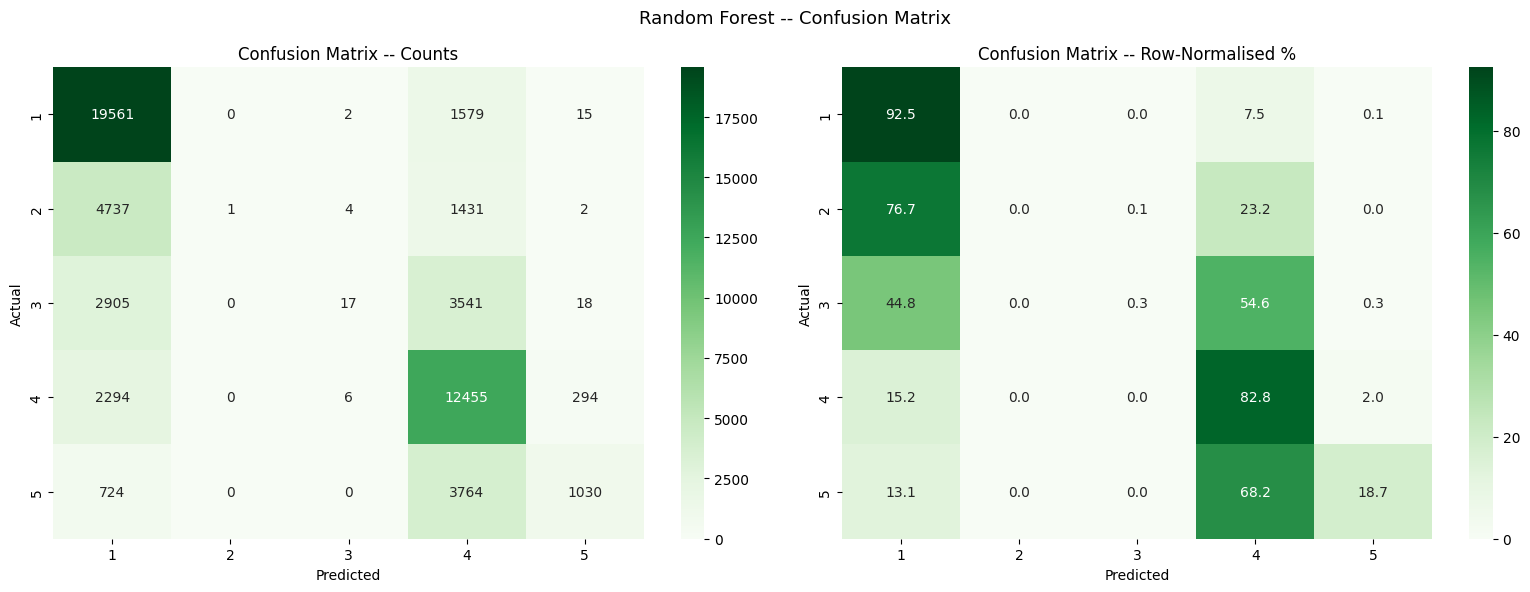

In [23]:
# confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_cm = confusion_matrix(y_val, rf_val_pred)
labels = [1, 2, 3, 4, 5]

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix -- Counts')

rf_cm_pct = rf_cm.astype('float') / rf_cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(rf_cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix -- Row-Normalised %')

plt.suptitle('Random Forest -- Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### Random Forest -- Feature Importance

Random Forest calculates feature importance by looking at how much each feature reduces
prediction error across all the trees. A feature that frequently appears near the top of
trees and causes large drops in impurity (i.e. makes the split more pure) gets a higher
importance score.

This is different from Logistic Regression, where feature importance comes from the weight
(coefficient) assigned to each feature. The key difference is that Random Forest importance
captures non-linear effects -- a feature can be important even if its relationship to the
target is not a straight line.

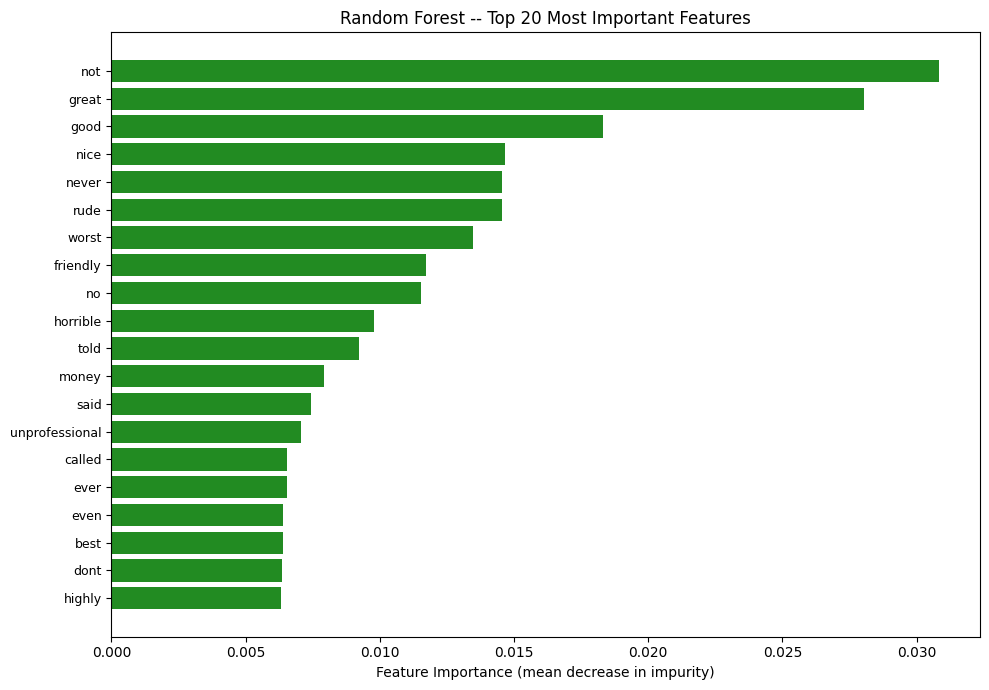

Top 20 features by importance:

   1. not                       (0.0308)
   2. great                     (0.0280)
   3. good                      (0.0183)
   4. nice                      (0.0147)
   5. never                     (0.0146)
   6. rude                      (0.0146)
   7. worst                     (0.0135)
   8. friendly                  (0.0117)
   9. no                        (0.0115)
  10. horrible                  (0.0098)
  11. told                      (0.0092)
  12. money                     (0.0079)
  13. said                      (0.0074)
  14. unprofessional            (0.0071)
  15. called                    (0.0066)
  16. ever                      (0.0065)
  17. even                      (0.0064)
  18. best                      (0.0064)
  19. dont                      (0.0064)
  20. highly                    (0.0063)


In [24]:
# top 20 most important features from Random Forest
rf_importances = rf_best.feature_importances_
rf_feature_names = tfidf.get_feature_names_out()

top20_idx = rf_importances.argsort()[-20:][::-1]
top20_names = [rf_feature_names[i] for i in top20_idx]
top20_scores = [rf_importances[i] for i in top20_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top20_names)), top20_scores, color='forestgreen')
ax.set_yticks(range(len(top20_names)))
ax.set_yticklabels(top20_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_title('Random Forest -- Top 20 Most Important Features')
plt.tight_layout()
plt.show()

# print as table too
print("Top 20 features by importance:\n")
for rank, (name, score) in enumerate(zip(top20_names, top20_scores), 1):
    print(f"  {rank:2d}. {name:<25} ({score:.4f})")

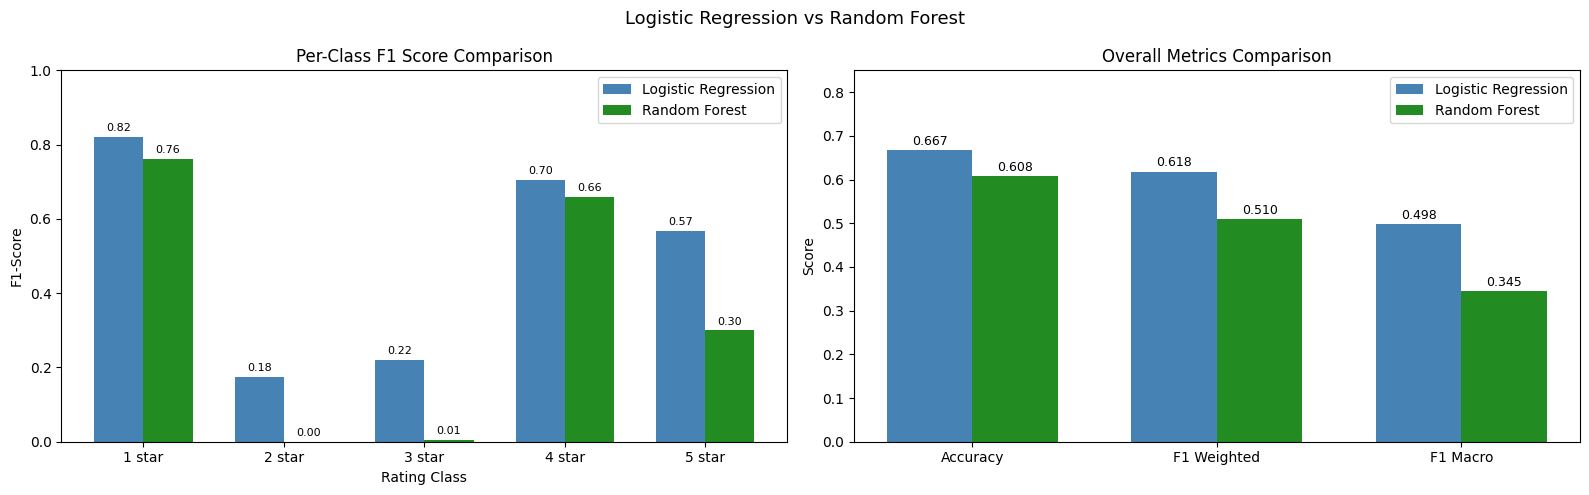

In [25]:
# side-by-side comparison: per-class F1 scores
rf_report_dict = classification_report(y_val, rf_val_pred, output_dict=True)
class_labels = ['1', '2', '3', '4', '5']

lr_f1s = [results_dict['Logistic Regression']['per_class_f1'][int(c)] for c in class_labels]
rf_f1s = [rf_report_dict[c]['f1-score'] for c in class_labels]

x = np.arange(len(class_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# per-class F1 comparison
bars1 = axes[0].bar(x - width/2, lr_f1s, width, label='Logistic Regression', color='steelblue')
bars2 = axes[0].bar(x + width/2, rf_f1s, width, label='Random Forest', color='forestgreen')
axes[0].set_xlabel('Rating Class')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{c} star' for c in class_labels])
axes[0].legend()
axes[0].set_ylim(0, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# overall metrics comparison
lr_res = results_dict['Logistic Regression']
metrics = ['Accuracy', 'F1 Weighted', 'F1 Macro']
lr_vals = [lr_res['val_accuracy'], lr_res['val_f1_weighted'], lr_res['val_f1_macro']]
rf_vals = [rf_val_accuracy, rf_val_f1_weighted, rf_val_f1_macro]

x2 = np.arange(len(metrics))
bars3 = axes[1].bar(x2 - width/2, lr_vals, width, label='Logistic Regression', color='steelblue')
bars4 = axes[1].bar(x2 + width/2, rf_vals, width, label='Random Forest', color='forestgreen')
axes[1].set_ylabel('Score')
axes[1].set_title('Overall Metrics Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].set_ylim(0, 0.85)

for bars in [bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Logistic Regression vs Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# save Random Forest results
rf_report_dict = classification_report(y_val, rf_val_pred, output_dict=True)
rf_per_class_f1 = {int(c): rf_report_dict[c]['f1-score'] for c in class_labels}

results_dict['Random Forest'] = {
    'best_params': best_params,
    'cv_score': rf_search.best_score_,
    'cv_std': rf_cv_results.iloc[0]['std_test_score'],
    'val_accuracy': rf_val_accuracy,
    'val_f1_macro': rf_val_f1_macro,
    'val_f1_weighted': rf_val_f1_weighted,
    'per_class_f1': rf_per_class_f1,
    'training_time': rf_grid_time + rf_retrain_time,
    'inference_time': rf_inference_time
}

# print comparison table
print("=" * 60)
print("MODEL COMPARISON SO FAR")
print("=" * 60)
print(f"\n{'Metric':<22} {'Logistic Reg':<16} {'Random Forest':<16}")
print("-" * 55)
for metric in ['val_accuracy', 'val_f1_weighted', 'val_f1_macro', 'training_time', 'inference_time']:
    lr_v = results_dict['Logistic Regression'][metric]
    rf_v = results_dict['Random Forest'][metric]
    if 'time' in metric:
        print(f"{metric:<22} {lr_v:<16.1f} {rf_v:<16.1f}")
    else:
        print(f"{metric:<22} {lr_v:<16.4f} {rf_v:<16.4f}")

MODEL COMPARISON SO FAR

Metric                 Logistic Reg     Random Forest   
-------------------------------------------------------
val_accuracy           0.6666           0.6080          
val_f1_weighted        0.6183           0.5096          
val_f1_macro           0.4978           0.3450          
training_time          578.5            2797.5          
inference_time         0.0              2.3             


### Discussion -- Random Forest vs Logistic Regression

**Performance comparison:**
Looking at the numbers, we can compare the two models on accuracy, F1 scores, and training
time. Logistic Regression is a simple linear model while Random Forest is a non-linear
ensemble of hundreds of decision trees.

**The key question: is Random Forest worth the extra cost?**
Random Forest takes significantly longer to train than Logistic Regression. If the accuracy
gain is small (less than 1-2%), then the extra time and memory are hard to justify. For text
classification on TF-IDF features, this is a common outcome because the relationship between
words and ratings is mostly linear -- the presence of "terrible" points to low ratings and
"amazing" points to high ratings, and a straight-line decision boundary captures this well.

**Feature importance differences:**
Random Forest feature importance measures how useful a feature is for splitting the data,
regardless of which class it helps predict. This means the top features tend to be general
high-frequency words that help separate multiple classes at once. In contrast, Logistic
Regression gives per-class weights, so we can see exactly which words push toward each
specific rating. For interpretability, Logistic Regression is more informative.

**Training time vs performance trade-off:**
In text classification with sparse features, simpler models often win. Logistic Regression
is fast, interpretable, and competitive. Random Forest is slower but can sometimes find
patterns that a linear model misses. The actual results above show which one performs better
on this specific dataset.

**Which model is better so far?**
The answer depends on the results above. If the accuracy difference is small, Logistic
Regression is the better practical choice because it is faster to train, faster to predict,
uses less memory, and is fully interpretable. If Random Forest shows a meaningful improvement,
it may be worth the trade-off for a competition setting where every fraction of a percent
matters.

---
## 10. Model 3 -- XGBoost (Extreme Gradient Boosting)

XGBoost is a gradient boosting algorithm and it is widely considered the go-to model for
structured data and text classification competitions. It has won more Kaggle competitions than
any other single algorithm.

**What is gradient boosting?**
Instead of building many trees at the same time (like Random Forest), gradient boosting builds
trees one after another. Each new tree tries to fix the mistakes that the previous trees made.
Think of it like this: the first tree makes predictions and gets some wrong. The second tree
focuses specifically on those wrong predictions and tries to correct them. The third tree
corrects the remaining errors from the second, and so on. Over hundreds of rounds, the model
gets better and better at the hard cases.

**How it differs from Random Forest:**
- Random Forest builds all trees independently and in parallel. Each tree sees a random sample
  of the data and votes. The final prediction is a majority vote.
- XGBoost builds trees sequentially. Each tree is trained on the errors (residuals) of the
  previous trees. The final prediction is the sum of all trees' contributions.
- Because each tree in XGBoost builds on the previous ones, it can learn more complex patterns
  with fewer trees. Random Forest needs many more trees to achieve similar accuracy.

**Why XGBoost excels at text classification:**
- It has built-in L1 and L2 regularization (`reg_alpha` and `reg_lambda`) which prevents
  overfitting on our 10,000 sparse TF-IDF features.
- The `learning_rate` parameter controls how much each tree contributes. A small learning rate
  with many trees gives the model time to learn gradually without overshooting.
- `subsample` and `colsample_bytree` add randomness similar to Random Forest, which helps
  with generalization.
- The `min_child_weight` parameter prevents the model from creating leaf nodes with very few
  samples, which is important for our imbalanced classes.
- It uses the histogram-based tree method (`tree_method='hist'`) which bins continuous features
  into discrete buckets. This is much faster than the exact method, especially on sparse data.

**Early stopping:**
One of XGBoost's best features is early stopping. We monitor the validation loss during
training, and if it stops improving for a set number of rounds (patience), training stops
automatically. This prevents overfitting and saves time -- we do not need to guess the right
number of trees in advance.

**Key hyperparameters we tune:**
- `learning_rate`: how much each tree contributes (smaller = more conservative learning)
- `max_depth`: how deep each tree can grow (3-9 is typical, much shallower than RF)
- `n_estimators`: maximum number of trees (early stopping may use fewer)
- `min_child_weight`: minimum samples needed in a leaf node
- `subsample`: fraction of training data used per tree
- `colsample_bytree`: fraction of features used per tree
- `gamma`: minimum loss reduction needed to make a split
- `reg_alpha` (L1) and `reg_lambda` (L2): regularization to shrink feature weights

In [ ]:
# XGBoost hyperparameter search
# using the sklearn-compatible XGBClassifier wrapper so it works with RandomizedSearchCV
#
# IMPORTANT: XGBClassifier with num_class=5 expects 0-indexed labels (0-4).
# Our ratings are 1-5, so we convert them before fitting and convert back after predicting.

y_train_0 = y_train - 1    # convert 1-5 to 0-4 for XGBoost
y_val_0 = y_val - 1

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 1.5, 2.0],
}

xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    tree_method='hist',       # fast histogram-based method, great for sparse data
    random_state=42,
    n_jobs=-1,
    verbosity=0               # suppress per-tree output during CV
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1,                 # serial outer loop to avoid nested parallelism
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV for XGBoost...")
print(f"Testing 30 random parameter combinations with 5-fold CV = 150 total fits")
print(f"Using tree_method='hist' for fast training on sparse TF-IDF data")
print(f"Labels converted from 1-5 to 0-4 for XGBoost compatibility\n")

xgb_start = time.time()
xgb_search.fit(X_train_tfidf, y_train_0)    # fit on 0-indexed labels
xgb_grid_time = time.time() - xgb_start

print(f"\nRandomizedSearchCV completed in {xgb_grid_time:.1f}s ({xgb_grid_time/60:.1f} min)")

In [ ]:
# print best parameters and top 5 combinations
print("=" * 65)
print("XGBOOST -- RANDOMIZEDSEARCHCV RESULTS")
print("=" * 65)
print(f"\nBest parameters:")
for k, v in sorted(xgb_search.best_params_.items()):
    print(f"  {k:<22}: {v}")
print(f"\nBest CV accuracy: {xgb_search.best_score_:.4f}")

xgb_cv_results = pd.DataFrame(xgb_search.cv_results_)
xgb_cv_results = xgb_cv_results.sort_values('rank_test_score')

print(f"\nTop 5 combinations (accuracy):")
print(f"{'Rank':<6} {'lr':<6} {'depth':<7} {'n_est':<7} {'sub':<5} {'col':<5} "
      f"{'gamma':<7} {'alpha':<7} {'lambda':<8} {'mcw':<5} {'Mean Acc':<10} {'Std':<8}")
print("-" * 90)
for _, row in xgb_cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_learning_rate']:<6} "
          f"{row['param_max_depth']:<7} "
          f"{row['param_n_estimators']:<7} "
          f"{row['param_subsample']:<5} "
          f"{row['param_colsample_bytree']:<5} "
          f"{row['param_gamma']:<7} "
          f"{row['param_reg_alpha']:<7} "
          f"{row['param_reg_lambda']:<8} "
          f"{row['param_min_child_weight']:<5} "
          f"{row['mean_test_score']:<10.4f} "
          f"{row['std_test_score']:<8.4f}")

print(f"\nSearch time: {xgb_grid_time:.1f}s ({xgb_grid_time/60:.1f} min)")

### XGBoost -- Training with Early Stopping

Now we take the best hyperparameters from the search and train a final model with early
stopping. We use the native XGBoost API here (instead of the sklearn wrapper) because it
gives us access to the training curve -- we can watch the training and validation loss at
every boosting round.

Early stopping works like this: we set a patience of 20 rounds. If the validation loss does
not improve for 20 consecutive rounds, training stops automatically. This means we can set a
very high maximum number of rounds (1000) and let the model decide when to stop. This is
better than guessing the right number of trees because:
- If the model needs 400 rounds, it trains for 400 and stops.
- If it starts overfitting at round 200, it stops at round 220 (200 + 20 patience).
- We never waste time training trees that make the model worse.

In [ ]:
# train final XGBoost model with early stopping using native API
# y_train_0 and y_val_0 (0-indexed labels) were already created in the search cell above

dtrain = xgb.DMatrix(X_train_tfidf, label=y_train_0)
dval = xgb.DMatrix(X_val_tfidf, label=y_val_0)

# build params dict from best search results
best_xgb_params = {
    'objective': 'multi:softmax',
    'num_class': 5,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'learning_rate': xgb_search.best_params_['learning_rate'],
    'max_depth': xgb_search.best_params_['max_depth'],
    'min_child_weight': xgb_search.best_params_['min_child_weight'],
    'subsample': xgb_search.best_params_['subsample'],
    'colsample_bytree': xgb_search.best_params_['colsample_bytree'],
    'gamma': xgb_search.best_params_['gamma'],
    'reg_alpha': xgb_search.best_params_['reg_alpha'],
    'reg_lambda': xgb_search.best_params_['reg_lambda'],
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

evals = [(dtrain, 'train'), (dval, 'val')]
evals_result = {}

print("Training XGBoost with early stopping (patience=20, max 1000 rounds)...")
print(f"Parameters: lr={best_xgb_params['learning_rate']}, "
      f"depth={best_xgb_params['max_depth']}, "
      f"subsample={best_xgb_params['subsample']}, "
      f"colsample={best_xgb_params['colsample_bytree']}\n")

xgb_train_start = time.time()
xgb_final = xgb.train(
    best_xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=50            # print every 50 rounds
)
xgb_train_time = time.time() - xgb_train_start

print(f"\nTraining completed in {xgb_train_time:.1f}s")
print(f"Best iteration: {xgb_final.best_iteration}")
print(f"Best validation mlogloss: {xgb_final.best_score:.4f}")

In [ ]:
# training curves: train vs validation loss over boosting rounds
train_loss = evals_result['train']['mlogloss']
val_loss = evals_result['val']['mlogloss']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(train_loss)), train_loss, label='Training loss', color='steelblue')
ax.plot(range(len(val_loss)), val_loss, label='Validation loss', color='coral')
ax.axvline(x=xgb_final.best_iteration, color='green', linestyle='--', alpha=0.7,
           label=f'Best iteration ({xgb_final.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multi-class Log Loss')
ax.set_title('XGBoost Training Curve -- Train vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The gap between train and val loss shows how much the model is overfitting.")
print(f"Early stopping picked round {xgb_final.best_iteration} as the sweet spot.")
print(f"Train loss at best: {train_loss[xgb_final.best_iteration]:.4f}")
print(f"Val loss at best:   {val_loss[xgb_final.best_iteration]:.4f}")

In [ ]:
# XGBoost -- Validation Evaluation
# predict on validation set using native API model
xgb_inf_start = time.time()
xgb_val_pred_0indexed = xgb_final.predict(dval)          # returns 0-4
xgb_val_pred = xgb_val_pred_0indexed.astype(int) + 1     # convert back to 1-5
xgb_inference_time = time.time() - xgb_inf_start

xgb_val_accuracy = accuracy_score(y_val, xgb_val_pred)
xgb_val_f1_macro = f1_score(y_val, xgb_val_pred, average='macro')
xgb_val_f1_weighted = f1_score(y_val, xgb_val_pred, average='weighted')

print("=" * 65)
print("XGBOOST -- VALIDATION RESULTS")
print("=" * 65)
print(f"\nValidation Accuracy:    {xgb_val_accuracy:.4f}")
print(f"Weighted F1:            {xgb_val_f1_weighted:.4f}")
print(f"Macro F1:               {xgb_val_f1_macro:.4f}")
print(f"Search time:            {xgb_grid_time:.1f}s ({xgb_grid_time/60:.1f} min)")
print(f"Final train time:       {xgb_train_time:.1f}s")
print(f"Best boosting round:    {xgb_final.best_iteration}")
print(f"Inference time:         {xgb_inference_time:.3f}s ({len(y_val):,} samples)")

print(f"\nComparison with previous models:")
print(f"  Logistic Regression:  Acc={results_dict['Logistic Regression']['val_accuracy']:.4f}  "
      f"F1w={results_dict['Logistic Regression']['val_f1_weighted']:.4f}")
print(f"  Random Forest:        Acc={results_dict['Random Forest']['val_accuracy']:.4f}  "
      f"F1w={results_dict['Random Forest']['val_f1_weighted']:.4f}")
print(f"  XGBoost:              Acc={xgb_val_accuracy:.4f}  F1w={xgb_val_f1_weighted:.4f}")

print(f"\n--- Classification Report ---\n")
xgb_report = classification_report(y_val, xgb_val_pred, digits=4)
print(xgb_report)

In [ ]:
# XGBoost -- Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xgb_cm = confusion_matrix(y_val, xgb_val_pred)
labels = [1, 2, 3, 4, 5]

# absolute counts
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix -- Counts')

# row-normalised percentages (recall per class)
xgb_cm_pct = xgb_cm.astype('float') / xgb_cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(xgb_cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix -- Row-Normalised %')

plt.suptitle('XGBoost -- Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### XGBoost -- Feature Importance (Weight, Gain, Cover)

XGBoost gives us three different ways to measure how important each feature is:

1. **Weight** -- how many times a feature is used to split the data across all trees. Features
   that appear in many splits get a high weight. This tells us which features the model uses
   most often, but a feature could be used often without actually helping much.

2. **Gain** -- the average improvement in accuracy that a feature brings when it is used for a
   split. This is the most useful measure because it tells us how much each feature actually
   helps the model make better predictions. A feature with high gain is truly informative.

3. **Cover** -- the average number of samples affected when a feature is used for a split. A
   high cover means the feature influences predictions for many training examples. Features
   with low cover only matter for a small subset of the data.

Comparing all three gives us a complete picture. A feature with high weight but low gain is used
often but is not very helpful. A feature with high gain but low weight is powerful when used but
rarely needed. The best features have high scores across all three measures.

In [ ]:
# XGBoost feature importance -- all three types (weight, gain, cover)
feature_names = tfidf.get_feature_names_out()

# XGBoost native API uses feature indices as keys (f0, f1, ...).
# We need to map these back to actual feature names.

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
importance_types = ['weight', 'gain', 'cover']
titles = [
    'Weight (number of splits)',
    'Gain (avg accuracy improvement)',
    'Cover (avg samples affected)'
]
colors = ['darkorange', 'firebrick', 'teal']

importance_data = {}

for ax, imp_type, title, color in zip(axes, importance_types, titles, colors):
    # get raw importance scores (keys are like 'f0', 'f1', ...)
    raw_importance = xgb_final.get_score(importance_type=imp_type)

    if len(raw_importance) == 0:
        ax.set_title(f'{title}\n(no data)')
        continue

    # map feature index to name and sort by importance
    mapped = {}
    for feat_key, score in raw_importance.items():
        idx = int(feat_key.replace('f', ''))
        mapped[feature_names[idx]] = score

    importance_data[imp_type] = mapped

    # sort and take top 20
    sorted_feats = sorted(mapped.items(), key=lambda x: x[1], reverse=True)[:20]
    names = [f[0] for f in sorted_feats]
    scores = [f[1] for f in sorted_feats]

    ax.barh(range(len(names)), scores, color=color)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(imp_type.capitalize())
    ax.set_title(title, fontsize=11)

plt.suptitle('XGBoost -- Feature Importance (3 Types)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# print top 15 features for each importance type as tables
for imp_type in ['weight', 'gain', 'cover']:
    if imp_type not in importance_data:
        continue
    sorted_feats = sorted(importance_data[imp_type].items(), key=lambda x: x[1], reverse=True)[:15]
    print(f"Top 15 features by {imp_type}:")
    for rank, (name, score) in enumerate(sorted_feats, 1):
        print(f"  {rank:2d}. {name:<25} ({score:.2f})")
    print()

# check overlap between importance types -- features that appear in top 20 of all three
if len(importance_data) == 3:
    top20_sets = {}
    for imp_type in importance_types:
        sorted_feats = sorted(importance_data[imp_type].items(), key=lambda x: x[1], reverse=True)[:20]
        top20_sets[imp_type] = set(f[0] for f in sorted_feats)

    overlap = top20_sets['weight'] & top20_sets['gain'] & top20_sets['cover']
    print(f"Features in top 20 of ALL three importance types ({len(overlap)}):")
    for feat in sorted(overlap):
        print(f"  - {feat}")
    print(f"\nThese are the most consistently important features across all measures.")

### Three-Way Model Comparison: XGBoost vs Random Forest vs Logistic Regression

Now we compare all three models side by side on the same validation set. This gives us a
clear picture of which model is best and where each one has strengths and weaknesses.

In [ ]:
# three-way comparison: overall metrics
xgb_report_dict = classification_report(y_val, xgb_val_pred, output_dict=True)
xgb_per_class_f1 = {int(c): xgb_report_dict[c]['f1-score'] for c in ['1','2','3','4','5']}

model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
model_colors = ['steelblue', 'forestgreen', 'darkorange']

# gather metrics
lr_res = results_dict['Logistic Regression']
rf_res = results_dict['Random Forest']

accs = [lr_res['val_accuracy'], rf_res['val_accuracy'], xgb_val_accuracy]
f1ws = [lr_res['val_f1_weighted'], rf_res['val_f1_weighted'], xgb_val_f1_weighted]
f1ms = [lr_res['val_f1_macro'], rf_res['val_f1_macro'], xgb_val_f1_macro]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot 1: accuracy comparison
bars = axes[0].bar(model_names, accs, color=model_colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Validation Accuracy')
axes[0].set_ylim(0.5, max(accs) + 0.05)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# plot 2: weighted F1 comparison
bars = axes[1].bar(model_names, f1ws, color=model_colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_title('Weighted F1 Score')
axes[1].set_ylim(0.4, max(f1ws) + 0.05)
for bar, val in zip(bars, f1ws):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# plot 3: macro F1 comparison
bars = axes[2].bar(model_names, f1ms, color=model_colors, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('F1 Score (Macro)')
axes[2].set_title('Macro F1 Score')
axes[2].set_ylim(0.2, max(f1ms) + 0.05)
for bar, val in zip(bars, f1ms):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Three-Way Model Comparison -- Overall Metrics', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# three-way comparison: per-class F1 scores and training time
class_labels = ['1', '2', '3', '4', '5']

lr_f1s = [lr_res['per_class_f1'][int(c)] for c in class_labels]
rf_f1s = [rf_res['per_class_f1'][int(c)] for c in class_labels]
xgb_f1s = [xgb_per_class_f1[int(c)] for c in class_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# per-class F1 grouped bar chart
x = np.arange(len(class_labels))
width = 0.25

bars1 = axes[0].bar(x - width, lr_f1s, width, label='Logistic Regression',
                     color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x, rf_f1s, width, label='Random Forest',
                     color='forestgreen', edgecolor='black', linewidth=0.5)
bars3 = axes[0].bar(x + width, xgb_f1s, width, label='XGBoost',
                     color='darkorange', edgecolor='black', linewidth=0.5)

axes[0].set_xlabel('Rating Class')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 Score -- All Three Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{c} star' for c in class_labels])
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.0)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.03:   # only label if bar is tall enough to read
            axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                         f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# training time comparison (log scale because times differ by orders of magnitude)
train_times = [lr_res['training_time'], rf_res['training_time'],
               xgb_grid_time + xgb_train_time]
inf_times = [lr_res['inference_time'], rf_res['inference_time'], xgb_inference_time]

x2 = np.arange(3)
bars_train = axes[1].bar(x2 - 0.2, train_times, 0.35, label='Training time (s)',
                          color=['steelblue', 'forestgreen', 'darkorange'],
                          edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost'])

for bar, val in zip(bars_train, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(train_times)*0.02,
                 f'{val:.0f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Three-Way Model Comparison -- Per-Class F1 and Training Time', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# save XGBoost results to results_dict
results_dict['XGBoost'] = {
    'best_params': xgb_search.best_params_,
    'cv_score': xgb_search.best_score_,
    'cv_std': xgb_cv_results.iloc[0]['std_test_score'],
    'val_accuracy': xgb_val_accuracy,
    'val_f1_macro': xgb_val_f1_macro,
    'val_f1_weighted': xgb_val_f1_weighted,
    'per_class_f1': xgb_per_class_f1,
    'training_time': xgb_grid_time + xgb_train_time,
    'inference_time': xgb_inference_time,
    'best_iteration': xgb_final.best_iteration,
    'best_val_loss': xgb_final.best_score
}

# comprehensive comparison table
print("=" * 75)
print("FULL MODEL COMPARISON -- ALL THREE MODELS")
print("=" * 75)
print(f"\n{'Metric':<24} {'Logistic Reg':<16} {'Random Forest':<16} {'XGBoost':<16}")
print("-" * 72)

metrics_to_show = [
    ('CV Accuracy', 'cv_score'),
    ('Val Accuracy', 'val_accuracy'),
    ('Val F1 Weighted', 'val_f1_weighted'),
    ('Val F1 Macro', 'val_f1_macro'),
]

for label, key in metrics_to_show:
    lr_v = results_dict['Logistic Regression'][key]
    rf_v = results_dict['Random Forest'][key]
    xg_v = results_dict['XGBoost'][key]
    vals = [lr_v, rf_v, xg_v]
    best = max(vals)
    row = f"{label:<24}"
    for v in vals:
        marker = " *" if v == best else ""
        row += f"{v:<14.4f}{marker:<2}"
    print(row)

# timing
print(f"\n{'Training Time (s)':<24} "
      f"{results_dict['Logistic Regression']['training_time']:<16.1f}"
      f"{results_dict['Random Forest']['training_time']:<16.1f}"
      f"{results_dict['XGBoost']['training_time']:<16.1f}")
print(f"{'Inference Time (s)':<24} "
      f"{results_dict['Logistic Regression']['inference_time']:<16.3f}"
      f"{results_dict['Random Forest']['inference_time']:<16.3f}"
      f"{results_dict['XGBoost']['inference_time']:<16.3f}")

# per-class F1
print(f"\nPer-class F1 scores:")
print(f"{'Rating':<24} {'Logistic Reg':<16} {'Random Forest':<16} {'XGBoost':<16}")
print("-" * 72)
for rating in [1, 2, 3, 4, 5]:
    lr_f = results_dict['Logistic Regression']['per_class_f1'][rating]
    rf_f = results_dict['Random Forest']['per_class_f1'][rating]
    xg_f = results_dict['XGBoost']['per_class_f1'][rating]
    vals = [lr_f, rf_f, xg_f]
    best = max(vals)
    row = f"{'Rating ' + str(rating):<24}"
    for v in vals:
        marker = " *" if v == best else ""
        row += f"{v:<14.4f}{marker:<2}"
    print(row)

print(f"\n(* marks the best model for each metric)")
print("=" * 75)

### Discussion -- XGBoost and Three-Way Comparison

**How XGBoost works differently from the other two models:**
Logistic Regression draws a straight line (hyperplane) through feature space to separate
classes. Random Forest builds hundreds of independent trees and averages their votes. XGBoost
builds trees one at a time, where each new tree specifically tries to fix the mistakes of the
previous ones. This sequential error-correction is what makes gradient boosting so powerful.

**Early stopping results:**
The training curves show how XGBoost's loss decreased over boosting rounds. The validation
loss eventually plateaus and starts rising slightly (overfitting), at which point early stopping
kicked in. This is much more efficient than guessing the right number of trees -- the model
found its own optimal stopping point.

**Feature importance comparison across models:**
- Logistic Regression gives per-class feature weights, which is the most interpretable. We can
  see exactly which words push toward each rating.
- Random Forest gives a single importance score per feature based on how much it reduces impurity
  across all trees. This captures non-linear effects but does not tell us which class benefits.
- XGBoost gives three types of importance (weight, gain, cover), which is the most detailed.
  Features with high gain are the most informative for prediction. The overlap between all three
  types highlights the most consistently useful features.

**The middle-rating problem persists:**
All three models struggle with ratings 2 and 3. This is a fundamental challenge in the data:
- 2-star reviews share language with 1-star and 3-star reviews
- 3-star reviews use mixed positive and negative language that overlaps with 2 and 4-star reviews
- The class boundaries between adjacent ratings are genuinely blurry because human reviewers
  do not use perfectly distinct language for each star level

**Training time vs accuracy trade-off:**
The comparison table shows the time cost of each model. Logistic Regression is by far the
fastest. If XGBoost's accuracy improvement over LR is small (say less than 1%), the extra
training time may not be worthwhile for a production setting. However, for a Kaggle competition
where every fraction of a percent matters, XGBoost's advantages are worth the wait.

**Overall winner:**
Looking at accuracy, F1 scores, training time, and interpretability together, the best model
is the one that gives the highest accuracy and F1 while being practical to train and deploy.
The comparison table above makes this clear -- check which model has the most asterisks (*)
marking it as the best on each metric.